Import Dataset

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d kunalgupta2616/dog-vs-cat-images-data

Dataset URL: https://www.kaggle.com/datasets/kunalgupta2616/dog-vs-cat-images-data
License(s): GPL-2.0
 93% 917M/991M [00:10<00:01, 45.0MB/s]
100% 991M/991M [00:10<00:00, 94.7MB/s]


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dog-vs-cat-images-data.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPool2D,Flatten

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogcat/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogcat/validation',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 25000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.


In [ ]:
# normalize
def process(image,label):
  image = tf.cast(image/255 , tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)



**Create CNN Model**

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation = 'relu',input_shape=(256,256,3)))
model.add(MaxPool2D(pool_size=(2,2), strides=2 , padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation = 'relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2 , padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation = 'relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2 , padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 84ms/step - accuracy: 0.6200 - loss: 0.6561 - val_accuracy: 0.7854 - val_loss: 0.4486
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 82ms/step - accuracy: 0.7779 - loss: 0.4669 - val_accuracy: 0.8482 - val_loss: 0.3378
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.8392 - loss: 0.3590 - val_accuracy: 0.8830 - val_loss: 0.2712
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 93ms/step - accuracy: 0.8986 - loss: 0.2421 - val_accuracy: 0.9006 - val_loss: 0.2456
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 82ms/step - accuracy: 0.9479 - loss: 0.1365 - val_accuracy: 0.9321 - val_loss: 0.1911
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.9713 - loss: 0.0802 - val_accuracy: 0.9405 - val_loss: 0.2002
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.9801 - loss: 0.0553 - val_accuracy: 0.9551 - val_loss: 0.1353
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.9847 - loss: 0.0434 - 

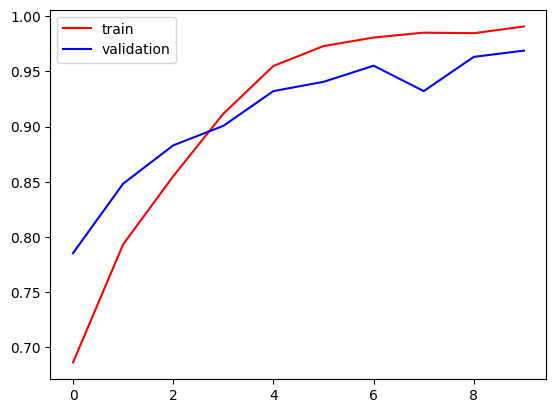

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

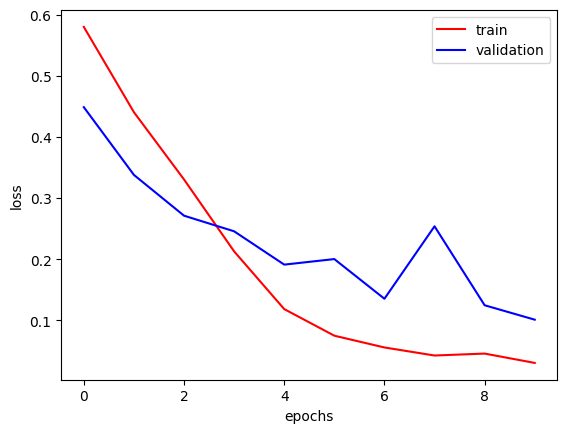

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogcat/test1',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 12500 files belonging to 1 classes.


In [ ]:
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
import cv2

In [ ]:
for i in range(5):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx]
    pred = np.argmax(model.predict(img[np.newaxis, ...]), axis=1)[0]
    label = "WithMask" if pred == 0 else "WithoutMask"
    plt.imshow(img)
    plt.title(f"Predicted: {label}, Actual: {list(label_map.keys())[y_test[idx]]}")
    plt.axis('off')
    plt.show()

In [ ]:
test_img = cv2.imread('/content/Dog.jpg')

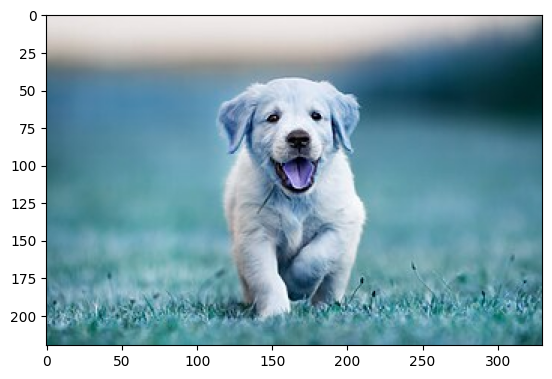

In [ ]:
plt.imshow(test_img)

In [ ]:
test2_img = cv2.imread('/content/dogcat/test1/test1/10023.jpg')

In [ ]:
test2_img.shape

(269, 360, 3)

In [ ]:
test2_img = cv2.resize(test2_img,(256,256))

In [ ]:
test2_input = test2_img.reshape((1,256,256,3))

In [ ]:
model.predict(test2_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[1.]], dtype=float32)

In [ ]:
def iscatordog(test2_img):
   test2_img = cv2.resize(test2_img,(256,256))
   test2_input = test2_img.reshape((1,256,256,3))
   p = int(model.predict(test2_input)[0][0])
   label = 'cat' if p == 0 else 'dog'
   plt.imshow(test2_img)
   plt.title(f"Predicted: it is a {label}")
   plt.show()


In [ ]:
import numpy as np


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


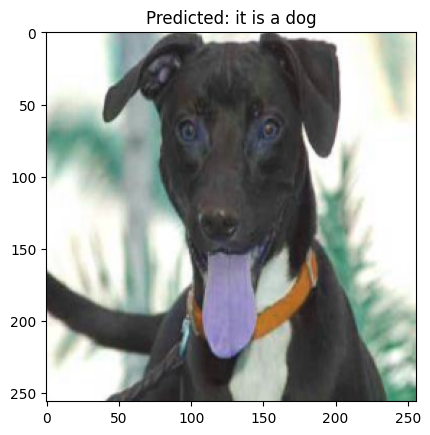

In [ ]:
myimage = cv2.imread('/content/dogcat/test1/test1/10023.jpg')
iscatordog(myimage)

Testing 5 random images from the directory...
------------------------------
Testing image: 7150.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


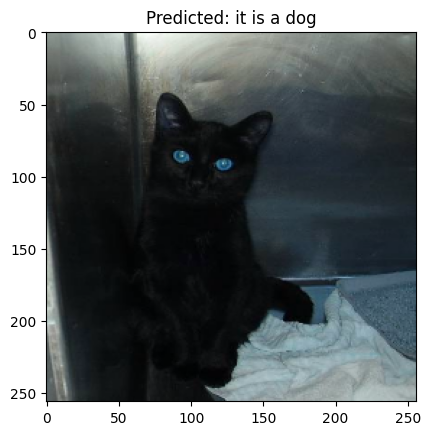

Testing image: 10003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


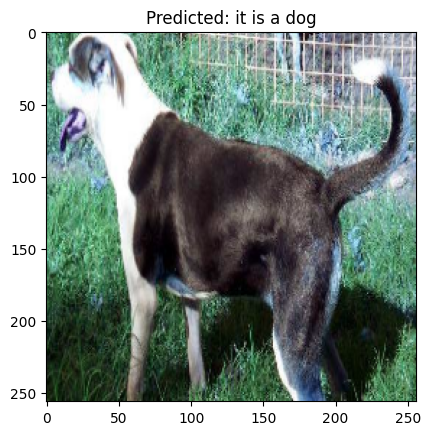

Testing image: 5467.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


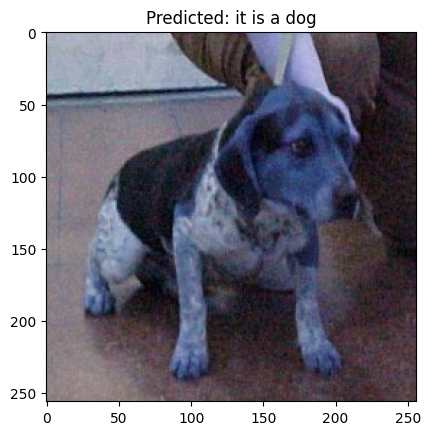

Testing image: 9875.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


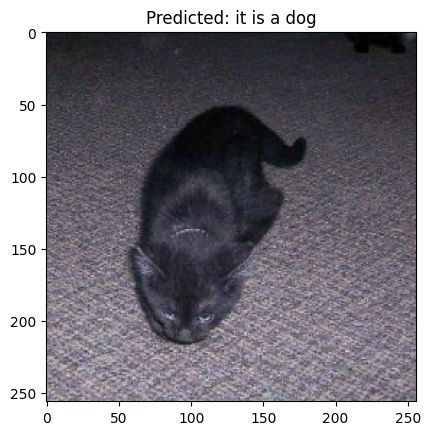

Testing image: 1325.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


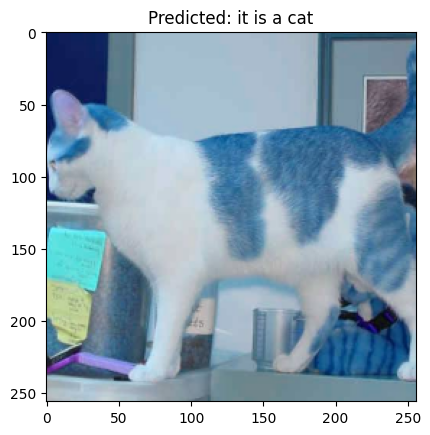

In [ ]:
import os
import cv2
import random
# Assuming numpy (np), model, and matplotlib.pyplot (plt) are already imported

# --- Setup Variables ---
TEST_DIR = '/content/dogcat/test1/test1/'
NUM_TESTS = 5  # Number of random images you want to test

# --- Get all image filenames ---
try:
    # List all files in the test directory
    all_files = os.listdir(TEST_DIR)

    # Filter for common image extensions (optional, but good practice)
    image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print(f"Error: No image files found in {TEST_DIR}")
    else:
        # --- Select Random Images ---
        # Ensure we don't try to select more images than available
        num_to_select = min(NUM_TESTS, len(image_files))

        # Select 'num_to_select' random filenames
        random_images = random.sample(image_files, num_to_select)

        # --- Loop and Test ---
        print(f"Testing {num_to_select} random images from the directory...")
        print("-" * 30)

        for image_name in random_images:
            # Create the full path to the image
            image_path = os.path.join(TEST_DIR, image_name)

            # Read the image using cv2
            current_image = cv2.imread(image_path)

            # Check if the image was read successfully (it won't be if the path is bad)
            if current_image is not None:
                print(f"Testing image: {image_name}")
                # Pass the loaded image array to your function
                iscatordog(current_image)
            else:
                print(f"Warning: Could not read image at path: {image_path}")

except FileNotFoundError:
    print(f"Error: The directory {TEST_DIR} was not found. Check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
# Assuming 'my_model' is your trained Keras model
model.save('my_cnn_model.h5')

# Download the file to your local machine
from google.colab import files
files.download('my_cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>